> **Chapter 12, Part 5** | Advanced lens. **Focus:** lineage graphs as governance objects, defect propagation, and the blast-radius descriptor that concentrates stewardship attention where it actually matters.

# Lineage Graphs and Fault Propagation

Data lineage is the most graph-shaped object in the data engineering stack and the one most teams treat as a static diagram. This notebook builds a lineage DAG, injects defects at a small number of leaf nodes, propagates them downstream, and computes a stewardship descriptor: blast radius across box scales.

The point is not to invent a new metric. The point is to rank transformation nodes by the structural concentration of risk they carry, so test budgets and review attention land where they count.

## Outputs

- a synthetic lineage DAG with named layers (sources, staging, marts, exposures)
- a defect-propagation simulator
- a blast-radius descriptor: number of distinct boxes the descendants of a node land in
- a stewardship priority list ranked by blast-radius spread
- a soft import of the Chapter 9 dbt manifest, with a fall-through to the synthetic DAG when the manifest is absent

## Supporting reading

- IBM on master data management: https://www.ibm.com/think/topics/master-data-management
- *End-to-end framework for data lineage analysis covering link pattern recognition, fault diagnosis, and early warning.* Scientific Reports (2025). https://nature.com/articles/s41598-025-34522-1
- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature* 433, 392-395.

## Failure note

If two transformation nodes have the same descendant count and the descriptor cannot tell them apart, the descriptor is not yet doing its job. The structural spread across box scales has to differentiate.

## How I would debug this

Inject a defect at a single source. Walk the propagation by hand for the first three downstream nodes. Then run the code on the same input. If they disagree, the propagation logic is wrong before any descriptor matters.


In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt


def synthetic_lineage(
    n_sources: int = 8,
    n_staging: int = 14,
    n_marts: int = 6,
    n_exposures: int = 4,
    seed: int = 7,
) -> nx.DiGraph:
    rng = np.random.default_rng(seed)
    g = nx.DiGraph()
    sources = [f"src_{i}" for i in range(n_sources)]
    staging = [f"stg_{i}" for i in range(n_staging)]
    marts = [f"mart_{i}" for i in range(n_marts)]
    exposures = [f"exp_{i}" for i in range(n_exposures)]
    for layer, nodes in [("source", sources), ("staging", staging), ("mart", marts), ("exposure", exposures)]:
        for n in nodes:
            g.add_node(n, layer=layer)

    for s in staging:
        for src in rng.choice(sources, size=2, replace=False):
            g.add_edge(src, s)
    for m in marts:
        for stg in rng.choice(staging, size=3, replace=False):
            g.add_edge(stg, m)
    for e in exposures:
        for m in rng.choice(marts, size=2, replace=False):
            g.add_edge(m, e)
    return g


lineage = synthetic_lineage()
print("nodes", lineage.number_of_nodes(), "edges", lineage.number_of_edges())
print("is DAG?", nx.is_directed_acyclic_graph(lineage))


nodes 32 edges 54
is DAG? True


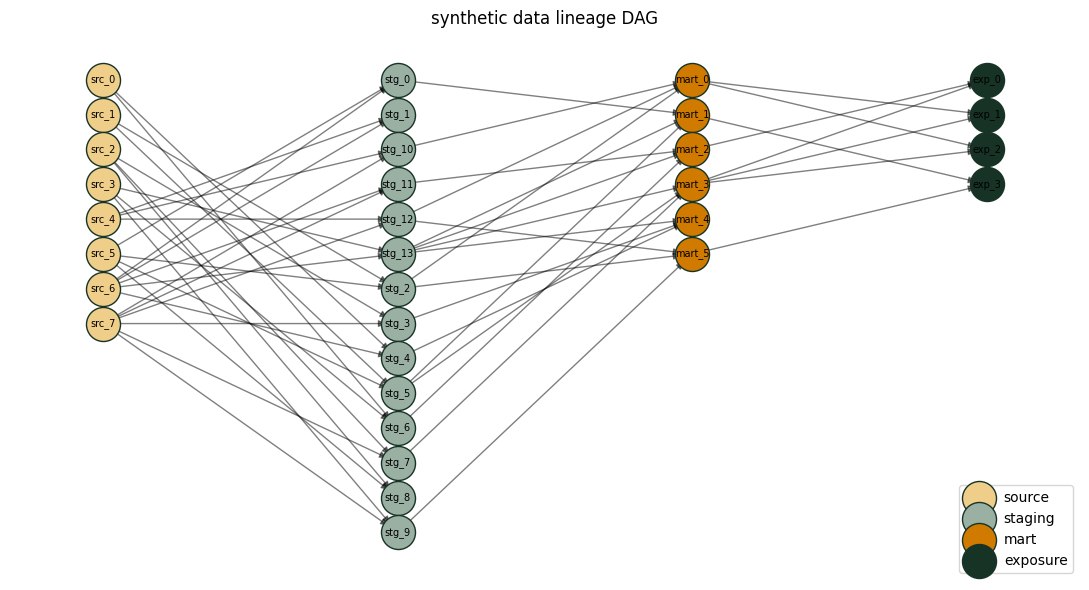

In [2]:
layer_order = {"source": 0, "staging": 1, "mart": 2, "exposure": 3}
layer_color = {"source": "#efce8a", "staging": "#9ab0a3", "mart": "#d17a00", "exposure": "#173326"}

pos = {}
for layer, x in layer_order.items():
    nodes_in_layer = [n for n, attrs in lineage.nodes(data=True) if attrs["layer"] == layer]
    for i, n in enumerate(sorted(nodes_in_layer)):
        pos[n] = (x, -i)

plt.figure(figsize=(11, 6))
for layer in layer_order:
    nodes_in_layer = [n for n, attrs in lineage.nodes(data=True) if attrs["layer"] == layer]
    nx.draw_networkx_nodes(
        lineage,
        pos,
        nodelist=nodes_in_layer,
        node_color=layer_color[layer],
        node_size=600,
        edgecolors="#173326",
        label=layer,
    )
nx.draw_networkx_edges(lineage, pos, alpha=0.5, arrows=True, arrowsize=10)
nx.draw_networkx_labels(lineage, pos, font_size=7)
plt.legend(scatterpoints=1, loc="lower right")
plt.title("synthetic data lineage DAG")
plt.axis("off")
plt.tight_layout()
plt.show()


In [3]:
def propagate_defect(g: nx.DiGraph, source_node: str) -> set[str]:
    """All nodes reachable from source_node, including source_node itself."""
    reachable = {source_node} | nx.descendants(g, source_node)
    return reachable


def blast_radius(g: nx.DiGraph, node: str, l_b: int = 2) -> dict:
    """Number of distinct boxes the descendants of `node` land in.

    Higher values indicate a defect at this node would spread across structurally
    distinct neighborhoods downstream rather than concentrating in one mart or
    one exposure family.
    """
    descendants = list(nx.descendants(g, node))
    if not descendants:
        return {"n_descendants": 0, "n_boxes": 0, "blast_score": 0.0}
    sub = g.subgraph([node] + descendants).to_undirected()
    dist = dict(nx.all_pairs_shortest_path_length(sub))
    aux = nx.Graph()
    aux.add_nodes_from(sub.nodes())
    nodes = list(sub.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            if dist[u].get(v, np.inf) >= l_b:
                aux.add_edge(u, v)
    coloring = nx.coloring.greedy_color(aux, strategy="largest_first")
    n_boxes = len(set(coloring.values()))
    return {
        "n_descendants": len(descendants),
        "n_boxes": n_boxes,
        "blast_score": n_boxes / max(len(descendants), 1),
    }


tagged = "src_0"
reachable = propagate_defect(lineage, tagged)
print(f"defect at {tagged} reaches {len(reachable)} downstream nodes:")
print(sorted(reachable))


defect at src_0 reaches 6 downstream nodes:
['exp_0', 'mart_2', 'mart_4', 'src_0', 'stg_4', 'stg_6']


In [4]:
rows = []
for node in lineage.nodes():
    r = blast_radius(lineage, node, l_b=2)
    r["node"] = node
    r["layer"] = lineage.nodes[node]["layer"]
    rows.append(r)

priority = pd.DataFrame(rows).sort_values(["n_boxes", "n_descendants"], ascending=[False, False]).reset_index(drop=True)
priority.head(12)


,n_descendants,n_boxes,blast_score,node,layer
0,15,10,0.666667,src_7,source
1,13,9,0.692308,src_6,source
2,12,8,0.666667,src_3,source
3,12,8,0.666667,src_5,source
4,10,6,0.600000,src_1,source
5,8,6,0.750000,src_2,source
6,8,6,0.750000,src_4,source
7,8,5,0.625000,stg_13,staging
8,6,5,0.833333,stg_5,staging
9,5,4,0.800000,stg_2,staging


In [5]:
import json
from pathlib import Path


def lineage_from_dbt_manifest(manifest_path: Path):
    if not manifest_path.exists():
        return None
    manifest = json.loads(manifest_path.read_text())
    g = nx.DiGraph()
    nodes = manifest.get("nodes", {})
    for node_id, attrs in nodes.items():
        g.add_node(node_id, layer=attrs.get("resource_type", "unknown"))
    parent_map = manifest.get("parent_map", {})
    for child, parents in parent_map.items():
        for parent in parents:
            if parent in g and child in g:
                g.add_edge(parent, child)
    return g


manifest_candidates = [
    Path("../../dbt/dbt_dq/target/manifest.json"),
    Path("../../../dbt/dbt_dq/target/manifest.json"),
]
real = None
for path in manifest_candidates:
    real = lineage_from_dbt_manifest(path)
    if real is not None:
        print(f"loaded dbt manifest from {path} with {real.number_of_nodes()} nodes")
        break
if real is None:
    print("no dbt manifest found; using the synthetic DAG above")


no dbt manifest found; using the synthetic DAG above


## Reading the result

The priority table ranks every node by the structural spread of its blast radius, not just by descendant count. A staging node with 12 descendants that all collapse into one downstream mart scores lower than a staging node with 8 descendants spread across 3 marts and 2 exposures. The first node is concentrated. The second node is structural.

This is the descriptor a stewardship lead should use to allocate test coverage and review effort. A defect at a high-spread node has worse downstream optics even when its raw descendant count is unimpressive.

## Where this can go wrong

- **Toy DAGs are too tidy.** Real lineage has back-edges (manual overrides), missing edges (undocumented downstream consumers), and multiple parallel pipelines that this synthetic does not capture.
- **Box size choice changes the ranking.** `l_b = 2` ranks nodes by immediate-neighborhood spread. `l_b = 4` smooths over local clusters. Run the descriptor at two box sizes and compare; if rankings flip, the spread is unstable.
- **Defect injection assumes a single source.** Real fault patterns are correlated across upstream sources. The propagation logic needs an upstream-correlation model to be operationally useful.

## Exercise

1. inject a defect at `src_3` instead of `src_0`. Which marts and exposures are touched? Is the blast-radius score larger or smaller?
2. compile the dbt project in `dbt/dbt_dq/` and re-run the soft-import cell. Does the real lineage have nodes whose `blast_score` exceeds the synthetic ones?
3. take your 12.0 lineage example and rank its nodes by blast radius. Pick the top-three node names and write a one-sentence stewardship action for each.
